# Run additional benchmarking on the subset that MARIO is able to integrate

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import os
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import cytovi
from mario.match import Mario 
from mario.match_utils import eval_matching_accuracy
from mario.match import pipelined_mario

/home/projects/amit/floriani/mambaforge/envs/cytovi_gpu/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/projects/amit/floriani/mambaforge/envs/cytovi_gpu/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/projects/amit/floriani/mambaforge/envs/cytovi_gpu/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/projects/amit/floriani/mambaforge/envs/cytovi_gpu/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/projects/amit/fl

In [ ]:
os.chdir('/home/projects/amit/floriani/Lab/PROJECTS/FlowVI/notebooks/')
figure_dir = '../figures/figure4/'

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams["savefig.dpi"] = 300

sc.settings.figdir = figure_dir
sc.set_figure_params(dpi_save = 300)
sc.settings.n_jobs = 40

In [3]:
def save_adata_as_csv(adata, path_prefix, adata_name, layer_key):
    adata_str = adata_name.replace('.h5ad', '')
    adata.obs.to_csv(f'{path_prefix}/{adata_str}_obs.csv')
    expr_df = pd.DataFrame(adata.layers[layer_key], columns=adata.var_names)
    expr_df.to_csv(f'{path_prefix}/{adata_str}_expr.csv')

In [4]:
# read data
model_path = '/home/projects/amit/floriani/Lab/PROJECTS/FlowVI/models/cross_tech_int/2025-08-20_Levine_Stuart'
adata = ad.read_h5ad(f'{model_path}/2025-08-21_Levine_Stuart_combined_adata_all_methods.h5ad')

In [5]:
# export expression and obs data to csv
save_adata_as_csv(adata, model_path, '2026-01-13_Levine_Stuart_combined_adata_MARIO.h5ad', 'std_scaled')

# run MARIO

In [7]:
# read data
expr_df = pd.read_csv(f'{model_path}/2026-01-13_Levine_Stuart_combined_adata_MARIO_expr.csv', index_col=0)
obs = pd.read_csv(f'{model_path}/2026-01-13_Levine_Stuart_combined_adata_MARIO_obs.csv', index_col=0)

expr_batch1 = expr_df.loc[(obs['batch'] == 0).values].copy()
expr_batch1 = expr_batch1.loc[:, expr_batch1.sum(axis=0) != 0]

expr_batch2 = expr_df.loc[(obs['batch'] == 1).values].copy()
expr_batch2 = expr_batch2.loc[:, expr_batch2.sum(axis=0) != 0]

/tmp/ipykernel_423228/3244213562.py:3: DtypeWarning: Columns (0,1,6,7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  obs = pd.read_csv(f'{model_path}/2026-01-13_Levine_Stuart_combined_adata_MARIO_obs.csv', index_col=0)


In [ ]:
# run mario
df1 = expr_batch1
df2 = expr_batch2


# run mario
final_matching_lst, embedding_lst = pipelined_mario(data_lst=[df1, df2])

# match ind
df1_rowidx=list(range(len(final_matching_lst[1])))
filtered_out=[i for i,x in enumerate(final_matching_lst[1]) if not x]

match_final_df1 =[e for e in df1_rowidx if not e in filtered_out]
match_final_df2 = [item for sublist in final_matching_lst[1] for item in sublist]

df1_filtered = df1.iloc[match_final_df1,]
df2_filtered = df2.iloc[match_final_df2,]

df1_filtered.to_csv(model_path + '/2026-01-14_df1_filtered.csv')
df2_filtered.to_csv(model_path + '/2026-01-14_df2_filtered.csv')

emb1 = embedding_lst[0]
emb2 = embedding_lst[1]

np.save(model_path + '/2026-01-14_embedding_batch1.npy', emb1)
np.save(model_path + '/2026-01-14_embedding_batch2.npy', emb2)

removed_df1_idx = df1.index.difference(df1_filtered.index)
removed_df2_idx = df2.index.difference(df2_filtered.index)
removed_idx = removed_df1_idx.union(removed_df2_idx).values

np.save(model_path + '/2026-01-14_removed_idx.npy', removed_idx)

In [58]:
# construct the adata object
# duplicated ind
dup_ind = df2_filtered.index[df2_filtered.index.duplicated()].to_numpy()
rm_ind = np.concatenate((removed_idx, dup_ind))

# remove duplicate cells
df2_filtered_unique = df2_filtered.iloc[~df2_filtered.index.isin(rm_ind),]
emb2_unique = emb2[~df2_filtered.index.isin(rm_ind)]

adata1 = ad.AnnData(df1_filtered)
adata1.obs['batch'] = '0'
adata1.layers['std_scaled'] = adata1.X.copy()
adata1.obsm['X_mario'] = emb1

adata2 = ad.AnnData(df2_filtered_unique)
adata2.obs['batch'] = '1'
adata2.layers['std_scaled'] = adata2.X.copy()
adata2.obsm['X_mario'] = emb2_unique

adata_filt = ad.concat([adata1, adata2], join = 'outer', index_unique=None)

/home/projects/amit/floriani/mambaforge/envs/mario/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/projects/amit/floriani/mambaforge/envs/mario/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [59]:
print('Input number of cells:', adata.shape[0])
print('Number of matched cells:', adata_filt.shape[0])
print('Fraction of unmatched cells:', len(rm_ind) / adata.shape[0])

Input number of cells: 62393
Number of matched cells: 32296
Fraction of unmatched cells: 0.6365938486689212


In [60]:
# quick hack to maintain nan_layer registration of original anndata
adata_filt = ad.concat([adata1, adata2], join = 'outer', index_unique=None)
ind_to_keep = adata_filt.obs.index.to_numpy().astype(int)

adata_filt_full = adata[ind_to_keep, :].copy()

# clear obsm fields and add new ones
del adata_filt_full.obsm
adata_filt_full.obsm['X_mario'] = adata_filt.obsm['X_mario'].copy()
adata_filt_full.obsm['X_unintegrated'] = adata.layers['std_scaled'][ind_to_keep,:].copy()

In [62]:
# save anndata
adata_filt_full.write_h5ad(f'{model_path}/2026-01-14_Levine_Stuart_combined_adata_MARIO_filtered.h5ad')

In [63]:
# export backbone expression and obs data to csv for comparison with other methods
adata_filt_bb = ad.concat([adata1, adata2], join = 'inner', index_unique=None)
adata_filt_bb.obs = adata.obs.iloc[ind_to_keep].copy()

adata_filt_bb.obsm['X_unintegrated'] = adata.layers['std_scaled'][ind_to_keep,:].copy()

save_adata_as_csv(adata_filt_bb, model_path, '2026-01-14_Levine_Stuart_combined_adata_MARIO_filtered_BB.h5ad', 'std_scaled')

# evaluate matching result

In [4]:
adata_filt_full = ad.read_h5ad(f'{model_path}/2026-01-14_Levine_Stuart_combined_adata_MARIO_filtered.h5ad')

/tmp/ipykernel_551239/4249394039.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_b.groupby([celltype_key, "status"], dropna=False)


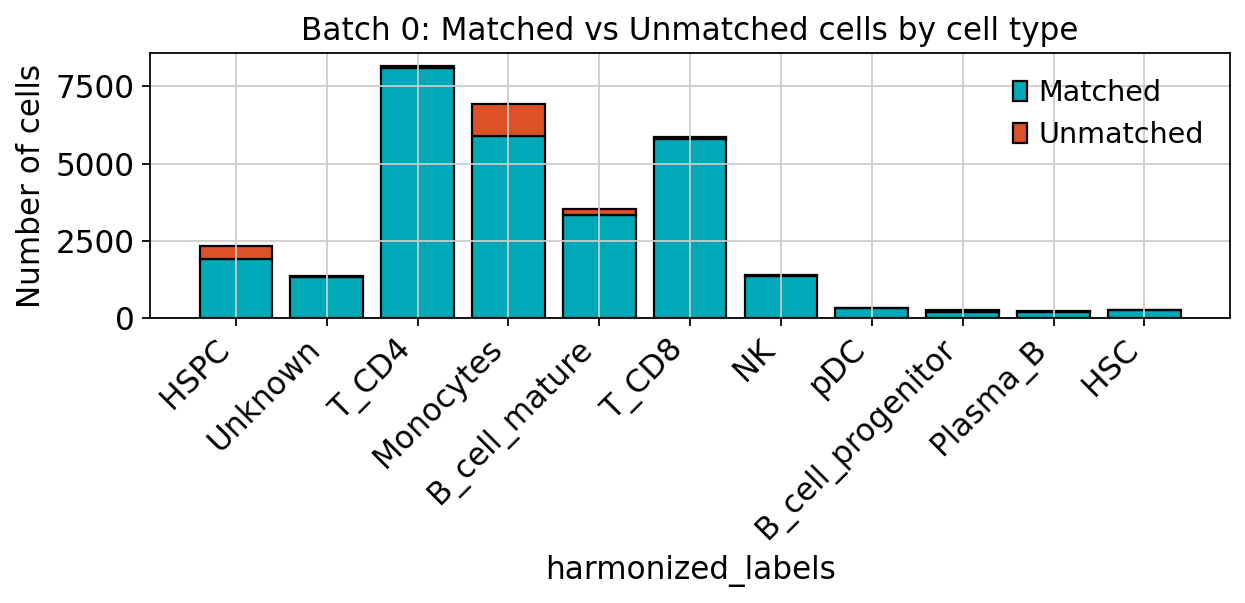

/tmp/ipykernel_551239/4249394039.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_b.groupby([celltype_key, "status"], dropna=False)


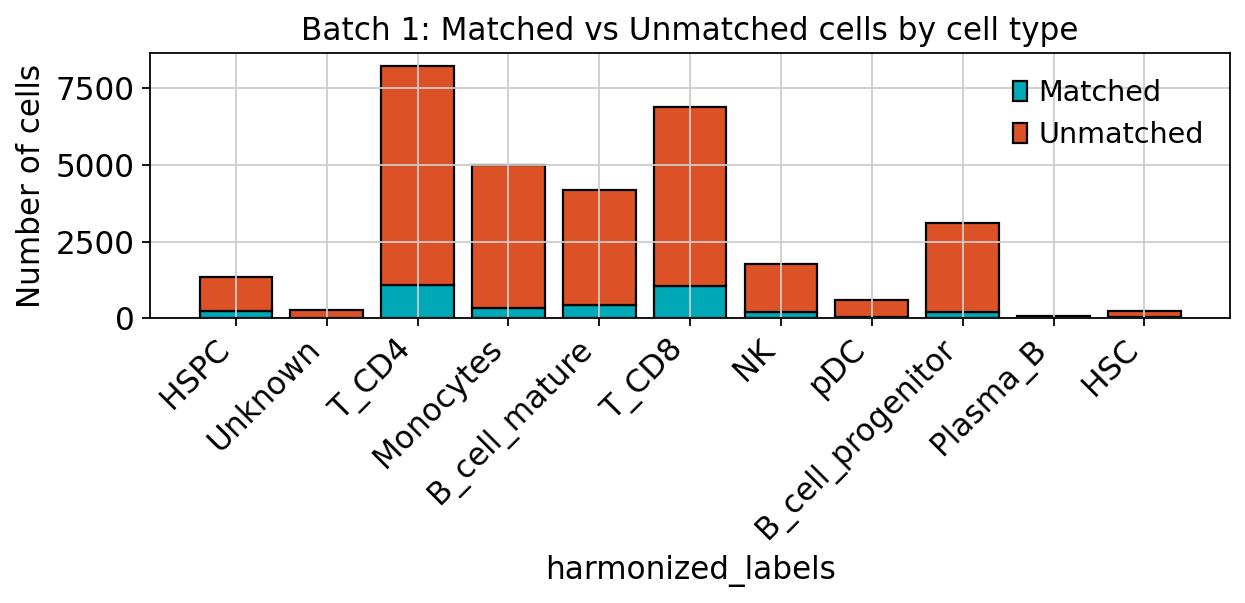

In [12]:
# plot matched vs unmatched cells by cell type for each batch
batch_key = "batch"
celltype_key = "harmonized_labels"
batches = adata.obs["batch"].drop_duplicates().tolist()
normalize = False


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs(figure_dir, exist_ok=True)

# matched cells = original cells that appear in the integrated AnnData
matched_ids = adata.obs_names.intersection(adata_filt_full.obs_names)

# fixed colors for consistency across plots
colors = {
    "Matched": "#00A9B8",
    "Unmatched": "#DD5126"
}

# base dataframe
df = adata.obs[[batch_key, celltype_key]].copy()
df["status"] = np.where(df.index.isin(matched_ids), "Matched", "Unmatched")

celltype_order = list(pd.unique(df[celltype_key]))

for b in batches:
    df_b = df[df[batch_key] == b]

    counts = (
        df_b.groupby([celltype_key, "status"], dropna=False)
            .size()
            .unstack("status", fill_value=0)
            .reindex(celltype_order, fill_value=0)
    )

    if normalize:
        counts = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

    fig, ax = plt.subplots(figsize=(8, 4))
    bottom = np.zeros(len(counts))

    for st in ["Matched", "Unmatched"]:
        vals = counts[st].to_numpy()
        ax.bar(
            np.arange(len(counts)),
            vals,
            bottom=bottom,
            color=colors[st],
            label=st,
            edgecolor="black",
            linewidth=1
        )
        bottom += vals

    ax.set_xticks(np.arange(len(counts)))
    ax.set_xticklabels(counts.index.tolist(), rotation=45, ha="right")
    ax.set_xlabel(celltype_key)
    ax.set_ylabel("Proportion" if normalize else "Number of cells")
    ax.set_title(f"Batch {b}: Matched vs Unmatched cells by cell type")
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.savefig(
        os.path.join(
            figure_dir,
            f"matched_unmatched_by_celltype_batch{b}{'_normalized' if normalize else ''}.pdf"
        ),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

# Run MARIO without batching

In [8]:
# run mario
df1 = expr_batch1
df2 = expr_batch2


# run mario
final_matching_lst, embedding_lst = pipelined_mario(data_lst=[df1, df2], n_batches=1)

# match ind
df1_rowidx=list(range(len(final_matching_lst[1])))
filtered_out=[i for i,x in enumerate(final_matching_lst[1]) if not x]

match_final_df1 =[e for e in df1_rowidx if not e in filtered_out]
match_final_df2 = [item for sublist in final_matching_lst[1] for item in sublist]

df1_filtered = df1.iloc[match_final_df1,]
df2_filtered = df2.iloc[match_final_df2,]

df1_filtered.to_csv(model_path + '/2026-01-15_df1_filtered_nobatch.csv')
df2_filtered.to_csv(model_path + '/2026-01-15_df2_filtered_nobatch.csv')

emb1 = embedding_lst[0]
emb2 = embedding_lst[1]

np.save(model_path + '/2026-01-15_embedding_batch1_nobatch.npy', emb1)
np.save(model_path + '/2026-01-15_embedding_batch2_nobatch.npy', emb2)

removed_df1_idx = df1.index.difference(df1_filtered.index)
removed_df2_idx = df2.index.difference(df2_filtered.index)
removed_idx = removed_df1_idx.union(removed_df2_idx).values

np.save(model_path + '/2026-01-15_removed_idx_nobatch.npy', removed_idx)

# 300 min comp time

Matching data_lst[0] with data_lst[1]
Now at batch 0
Matching using overlapping features...


/home/projects/amit/floriani/mambaforge/envs/mario/lib/python3.8/site-packages/mario/match.py:75: UserWarning: n_components exceed the number of overlapping features, set it to be the number of overlapping features.
  warnings.warn("n_components exceed the number of overlapping features,"


Matching using all features...


/home/projects/amit/floriani/mambaforge/envs/mario/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but CCA was fitted without feature names
  warnings.warn(


Finding the best interpolated matching...
Filtering bad matched pairs...


/home/projects/amit/floriani/mambaforge/envs/mario/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Stitching batch-wise matchings together...
Matching is done, calculating joint embeddings...
Saving the results...
Done!


In [9]:
# construct the adata object
# duplicated ind
dup_ind = df2_filtered.index[df2_filtered.index.duplicated()].to_numpy()
rm_ind = np.concatenate((removed_idx, dup_ind))

# remove duplicate cells
df2_filtered_unique = df2_filtered.iloc[~df2_filtered.index.isin(rm_ind),]
emb2_unique = emb2[~df2_filtered.index.isin(rm_ind)]

adata1 = ad.AnnData(df1_filtered)
adata1.obs['batch'] = '0'
adata1.layers['std_scaled'] = adata1.X.copy()
adata1.obsm['X_mario'] = emb1

adata2 = ad.AnnData(df2_filtered_unique)
adata2.obs['batch'] = '1'
adata2.layers['std_scaled'] = adata2.X.copy()
adata2.obsm['X_mario'] = emb2_unique

adata_filt = ad.concat([adata1, adata2], join = 'outer', index_unique=None)

/home/projects/amit/floriani/mambaforge/envs/mario/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/projects/amit/floriani/mambaforge/envs/mario/lib/python3.8/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [10]:
# quick hack to maintain nan_layer registration of original anndata
adata_filt = ad.concat([adata1, adata2], join = 'outer', index_unique=None)
ind_to_keep = adata_filt.obs.index.to_numpy().astype(int)

adata_filt_full = adata[ind_to_keep, :].copy()

# clear obsm fields and add new ones
del adata_filt_full.obsm
adata_filt_full.obsm['X_mario'] = adata_filt.obsm['X_mario'].copy()
adata_filt_full.obsm['X_unintegrated'] = adata.layers['std_scaled'][ind_to_keep,:].copy()

# save anndata
adata_filt_full.write_h5ad(f'{model_path}/2026-01-14_Levine_Stuart_combined_adata_MARIO_filtered_nobatch.h5ad')

/tmp/ipykernel_25435/1794082227.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_b.groupby([celltype_key, "status"], dropna=False)


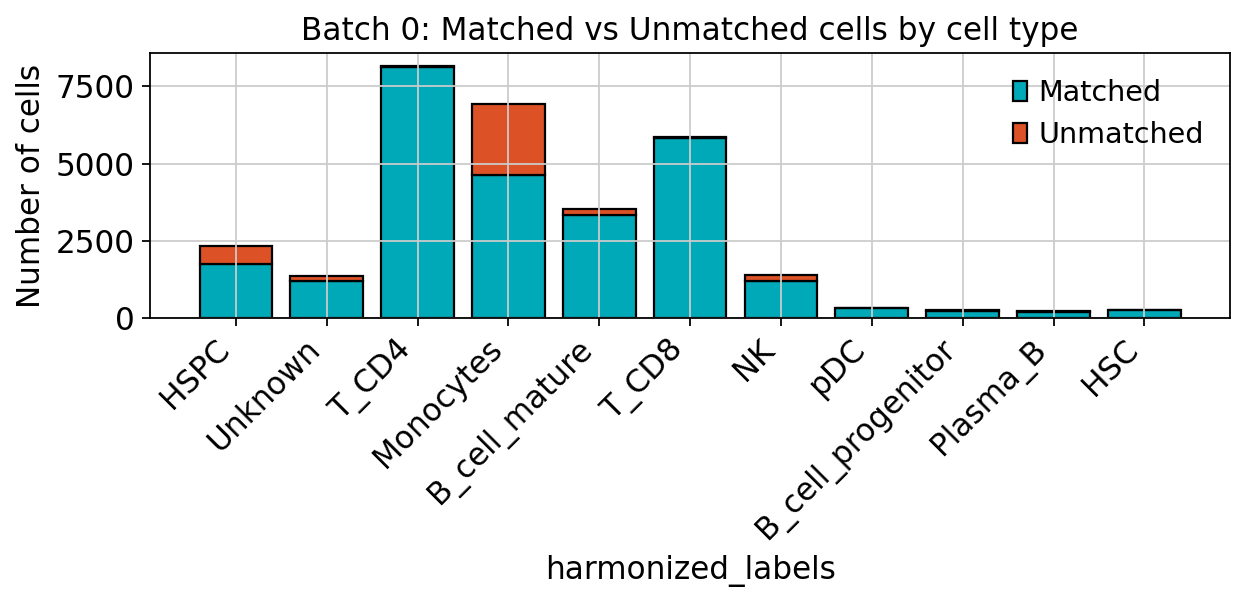

/tmp/ipykernel_25435/1794082227.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_b.groupby([celltype_key, "status"], dropna=False)


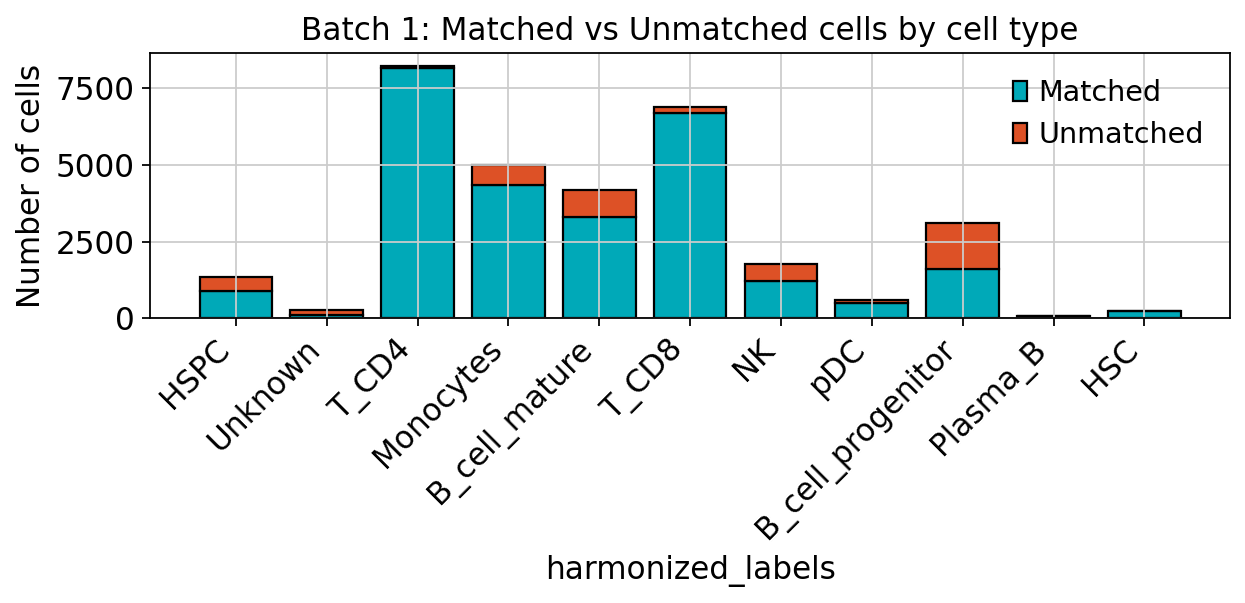

In [31]:
# plot matched vs unmatched cells by cell type for each batch
batch_key = "batch"
celltype_key = "harmonized_labels"
batches = adata.obs["batch"].drop_duplicates().tolist()
normalize = False

os.makedirs(figure_dir, exist_ok=True)

# matched cells = original cells that appear in the integrated AnnData
matched_ids = adata.obs_names.intersection(adata_filt_full.obs_names)

# fixed colors for consistency across plots
colors = {
    "Matched": "#00A9B8",
    "Unmatched": "#DD5126"
}

# base dataframe
df = adata.obs[[batch_key, celltype_key]].copy()
df["status"] = np.where(df.index.isin(matched_ids), "Matched", "Unmatched")

celltype_order = list(pd.unique(df[celltype_key]))

for b in batches:
    df_b = df[df[batch_key] == b]

    counts = (
        df_b.groupby([celltype_key, "status"], dropna=False)
            .size()
            .unstack("status", fill_value=0)
            .reindex(celltype_order, fill_value=0)
    )

    if normalize:
        counts = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

    fig, ax = plt.subplots(figsize=(8, 4))
    bottom = np.zeros(len(counts))

    for st in ["Matched", "Unmatched"]:
        vals = counts[st].to_numpy()
        ax.bar(
            np.arange(len(counts)),
            vals,
            bottom=bottom,
            color=colors[st],
            label=st,
            edgecolor="black",
            linewidth=1
        )
        bottom += vals

    ax.set_xticks(np.arange(len(counts)))
    ax.set_xticklabels(counts.index.tolist(), rotation=45, ha="right")
    ax.set_xlabel(celltype_key)
    ax.set_ylabel("Proportion" if normalize else "Number of cells")
    ax.set_title(f"Batch {b}: Matched vs Unmatched cells by cell type")
    ax.legend(frameon=False)

    plt.tight_layout()
    plt.savefig(
        os.path.join(
            figure_dir,
            f"matched_unmatched_by_celltype_batch{b}{'_normalized' if normalize else ''}_nobatch.pdf"
        ),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

# read all embeddings and proceed to scib

In [6]:
adata_filt = ad.read_h5ad(f'{model_path}/2026-01-14_Levine_Stuart_combined_adata_MARIO_filtered_nobatch.h5ad')

In [14]:
# export bb marker expression for comparison with other methods
bb_markers = adata_filt.var_names[adata_filt.var.all(axis=1)]
adata_filt_bb = adata_filt[:, bb_markers].copy()

save_adata_as_csv(adata_filt_bb, model_path, '2026-01-14_Levine_Stuart_combined_adata_MARIO_filtered_nobatch_bb.h5ad', 'std_scaled')

In [17]:
# read results form all methods
adata_filt = ad.read_h5ad(f'{model_path}/2026-01-14_Levine_Stuart_combined_adata_cytovi_harmony_MARIO_filtered_nobatch.h5ad')
adata_filt.obsm['X_FastMNN'] = pd.read_csv(f'{model_path}/2026-01-14_Levine_Stuart_combined_adata_MARIO_filtered_nobatch_bb_FastMNN.csv').to_numpy()
adata_filt.obsm['X_Cycombine'] = pd.read_csv(f'{model_path}/2026-01-14_Levine_Stuart_combined_adata_MARIO_filtered_nobatch_bb_Cycombine.csv').to_numpy()

In [19]:
# save anndata
adata_filt.write(f'{model_path}/2026-01-19_Levine_Stuart_combined_adata_MARIO_filtered_nobatch_all_methods.h5ad')

In [20]:
# perform scib
bb_markers = adata_filt.var_names[adata_filt.var.all(axis=1)]
adata_bm = adata_filt[adata_filt.obs['harmonized_labels'] != 'Unknown', bb_markers].copy()
adata_bm.obs['harmonized_labels'].cat.remove_unused_categories()

adata_bm = cytovi.pp.subsample(adata_bm, n_obs = 20000, groupby = 'batch').copy()
adata_bm.X = adata_bm.layers['std_scaled'].copy()

latent_obsm_keys = [*adata_bm.obsm.keys()]

/home/projects/amit/floriani/github_repos/CytoVI_dev/src/cytovi/pp/cyto_pp.py:355: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  index = adata.obs.groupby(groupby, as_index=False).apply(


In [ ]:
# perform the actual benchmarking
from scib_metrics.benchmark import Benchmarker, BioConservation

biocon = BioConservation(nmi_ari_cluster_labels_leiden = True, nmi_ari_cluster_labels_kmeans = False)

bm = Benchmarker(
    adata_bm,
    batch_key="batch",
    label_key="harmonized_labels",
    embedding_obsm_keys=latent_obsm_keys,
    pre_integrated_embedding_obsm_key='X_unintegrated',
    bio_conservation_metrics = biocon,
    n_jobs=40,
)
bm.benchmark()

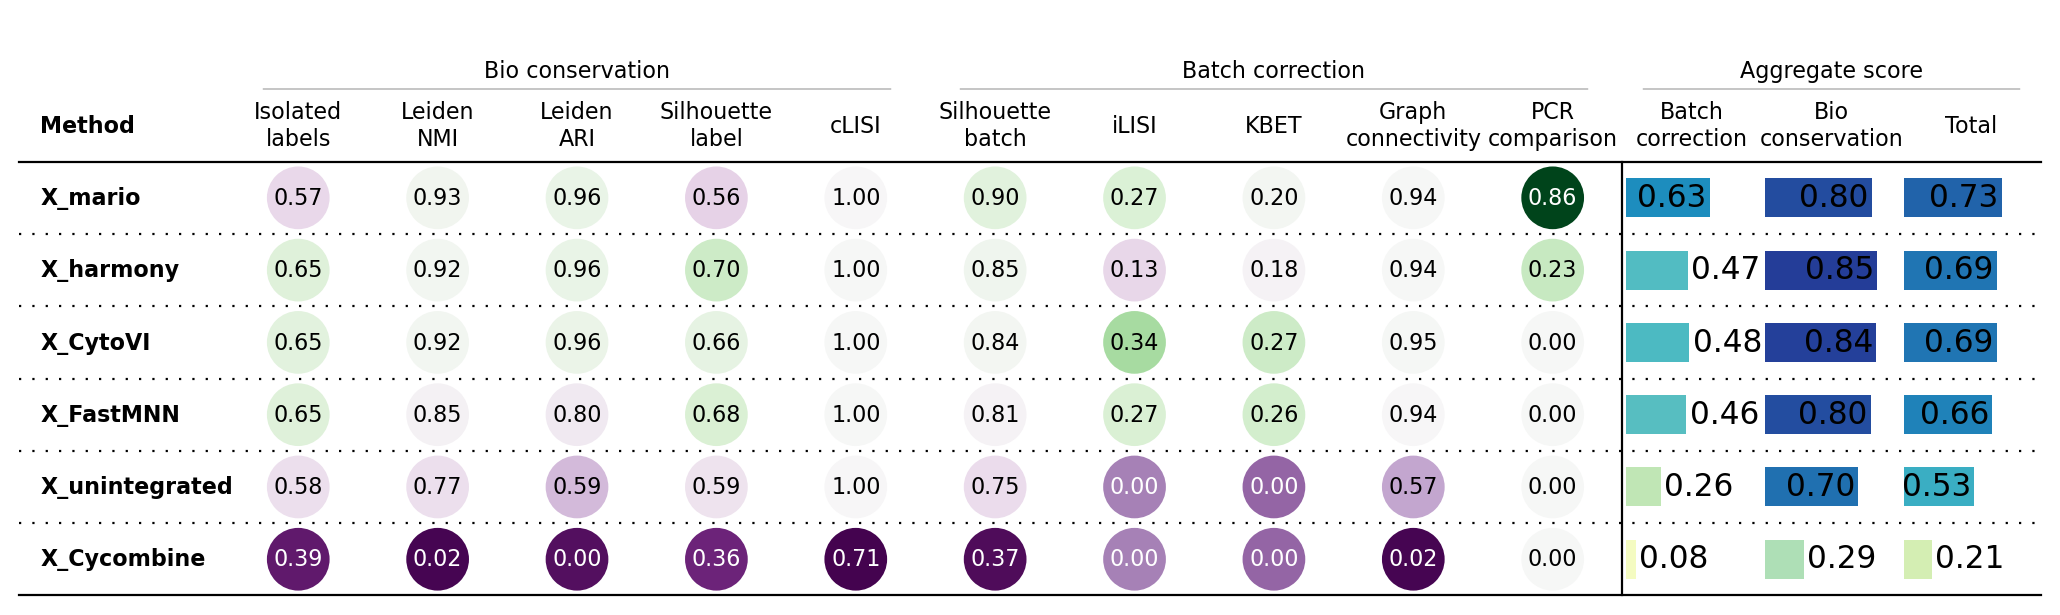

In [22]:
bm.plot_results_table(min_max_scale = False, show = False)

In [23]:
# save bm results as csv
bm.get_results(min_max_scale=False).to_csv(f'{model_path}/2026-01-19_Levine_Stuart_combined_benchmarking_results_MARIO_subset_nobatch.csv')

In [28]:
# read again and do costumn plotting
bm_res = pd.read_csv(f'{model_path}/2026-01-19_Levine_Stuart_combined_benchmarking_results_MARIO_subset_nobatch.csv', index_col = 0)
bm_res.rename(index = {'X_CytoVI': 'X_CytoVI_zscore', 
                       'X_mario': 'X_mario_zscore',
                       'X_FastMNN': 'X_FastMNN_zscore', 
                       'X_harmony': 'X_harmony_zscore', 
                       'X_unintegrated': 'X_unintegrated_zscore',
                       'X_Cycombine': 'X_Cycombine_zscore'
                    }, inplace=True)

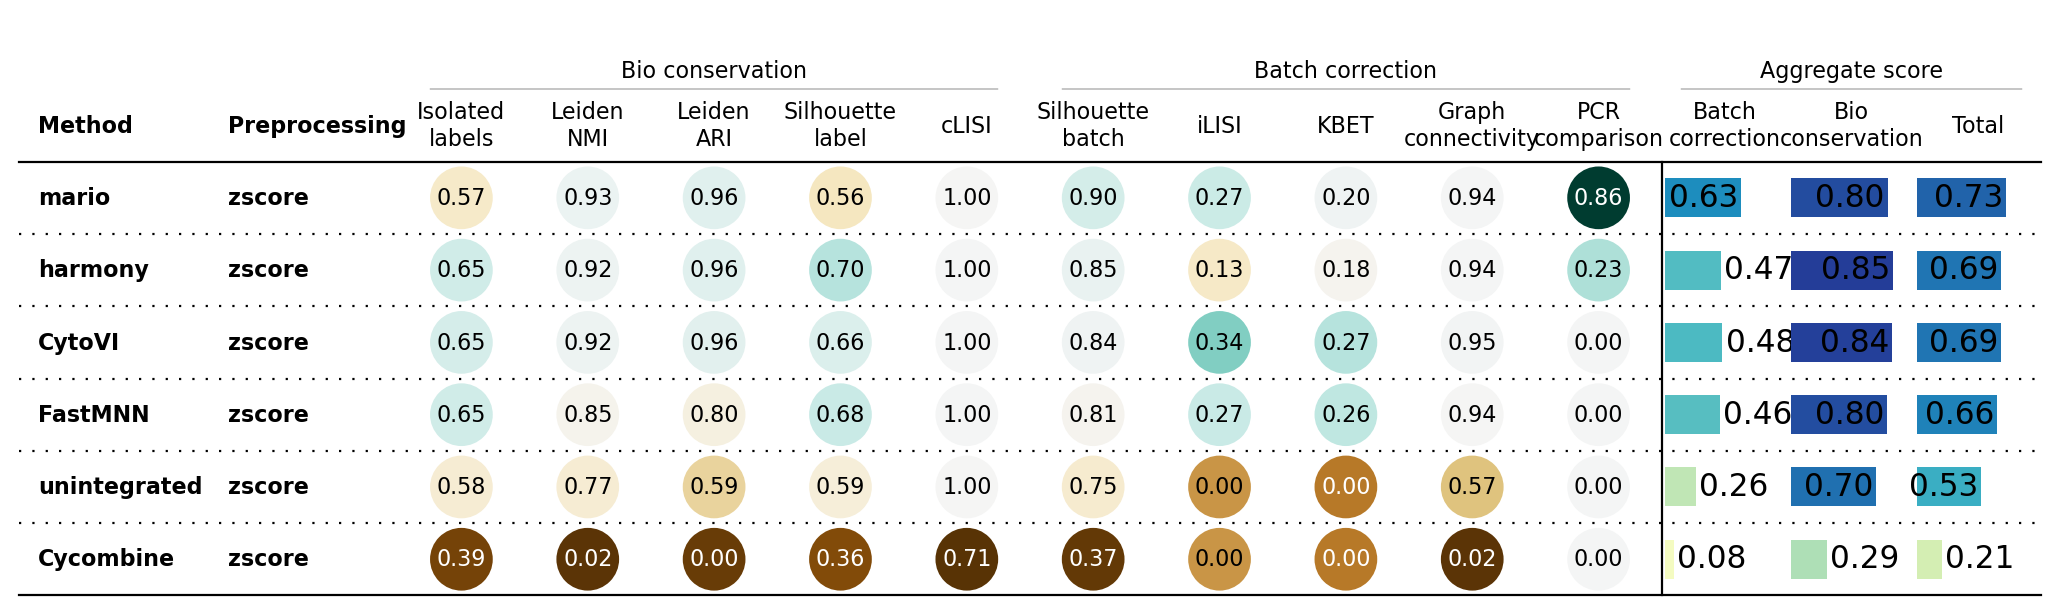

In [29]:
from plottable import ColumnDefinition, Table
from plottable.cmap import normed_cmap
from plottable.plots import bar
import matplotlib.pyplot as plt
import numpy as np

cmap_fn = lambda col_data: normed_cmap(col_data, cmap=plt.cm.BrBG, num_stds=2.5)

# Drop 'Metric Type' from the DataFrame
plot_df = bm_res.drop('Metric Type', axis=0)
num_embeds = plot_df.shape[0]

# Sort by total score
plot_df = plot_df.sort_values(by="Total", ascending=False).astype(np.float64)
plot_df["Method"] = plot_df.index

# Split the Method column into two columns, filling missing parts with empty strings
split_methods = plot_df['Method'].str.split('_', n=2, expand=True)
plot_df['Method'] = split_methods[1]
plot_df['Preprocessing'] = split_methods[2]
# plot_df['Method_Part2'] = split_methods[1].fillna('')

# Rearrange the columns to put the new Method_Part1 and Method_Part2 columns at the beginning
cols = ['Method', 'Preprocessing'] + [col for col in plot_df.columns if col not in ['Method', 'Preprocessing']]
plot_df = plot_df[cols]

# plot_df = plot_df.drop(columns=['Method'])

# Split columns by metric type
score_cols = bm_res.columns[bm_res.loc['Metric Type'] == 'Aggregate score']
other_cols = bm_res.columns[bm_res.loc['Metric Type'] != 'Aggregate score']
other_cols = [col for col in other_cols if col != 'New_col']

column_definitions = [
    ColumnDefinition("Method", width=1.5, textprops={"ha": "left", "weight": "bold"}),
    ColumnDefinition("Preprocessing", width=1.5, textprops={"ha": "left", "weight": "bold"}),
]

# Circles for the metric values
column_definitions += [
    ColumnDefinition(
        col,
        title=col.replace(" ", "\n", 1),
        width=1,
        textprops={
            "ha": "center",
            "bbox": {"boxstyle": "circle", "pad": 0.25},
        },
        cmap=cmap_fn(plot_df[col]),
        group=bm_res.loc['Metric Type', col],
        formatter="{:.2f}",
    )
    for i, col in enumerate(other_cols)
]

# Bars for the aggregate scores
column_definitions += [
    ColumnDefinition(
        col,
        width=1,
        title=col.replace(" ", "\n", 1),
        plot_fn=bar,
        plot_kw={
            "cmap": plt.cm.YlGnBu,
            "plot_bg_bar": False,
            "annotate": True,
            "height": 0.9,
            "formatter": "{:.2f}",
        },
        group=bm_res.loc['Metric Type', col],
        border="left" if i == 0 else None,
    )
    for i, col in enumerate(score_cols)
]

# Allow to manipulate text post-hoc (in illustrator)
size = 1

with plt.rc_context({"svg.fonttype": "none"}):
    fig, ax = plt.subplots(figsize=(len(bm_res.columns) * 1.25 * size, 3 + 0.3 * num_embeds * size))
    tab = Table(
        plot_df,
        cell_kw={
            "linewidth": 0,
            "edgecolor": "k",
        },
        column_definitions=column_definitions,
        ax=ax,
        row_dividers=True,
        footer_divider=True,
        textprops={"fontsize": 10, "ha": "center"},
        row_divider_kw={"linewidth": 1, "linestyle": (0, (1, 5))},
        col_label_divider_kw={"linewidth": 1, "linestyle": "-"},
        column_border_kw={"linewidth": 1, "linestyle": "-"},
        index_col='Method', 
    ).autoset_fontcolors(colnames=plot_df.columns)

plt.show()
fig.savefig(os.path.join(figure_dir, "scib_results_cross_int_MARIO_sub.pdf"), facecolor=ax.get_facecolor(), dpi=300)

In [24]:
for key in latent_obsm_keys:
    sc.pp.neighbors(adata_bm, use_rep=key)
    sc.tl.umap(adata_bm)
    adata_bm.obsm[f"X_umap_{key[2:]}"] = adata_bm.obsm['X_umap'].copy()

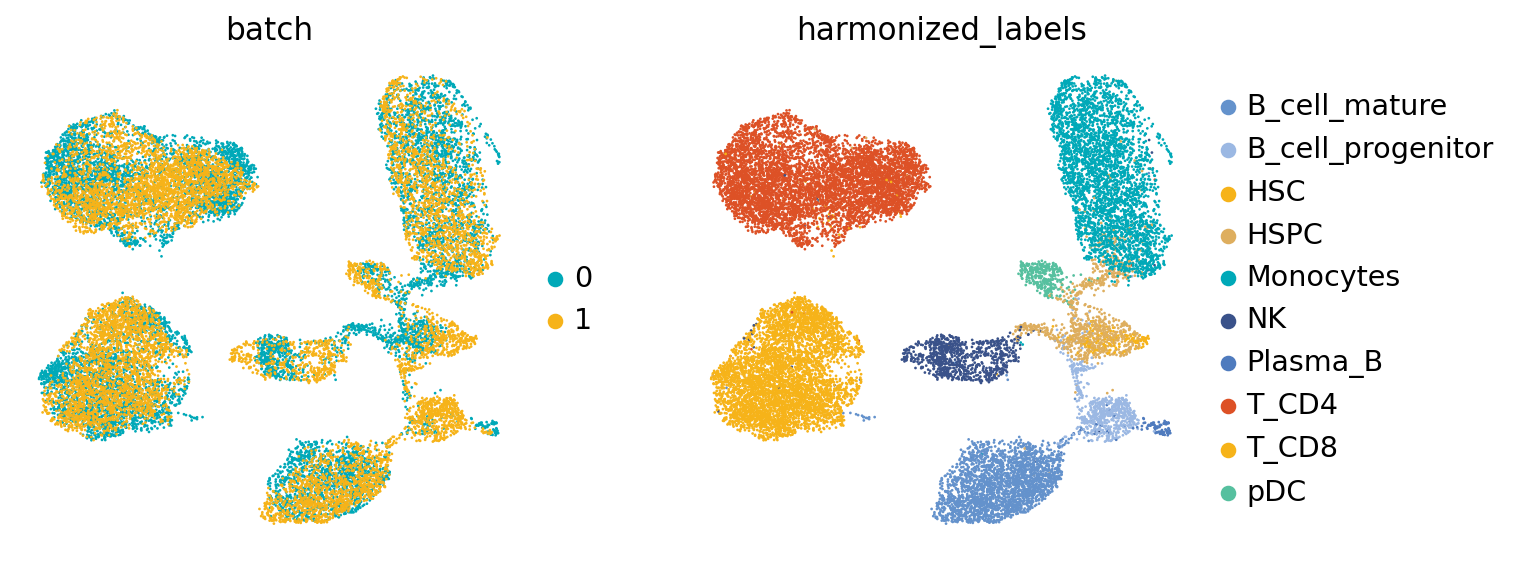

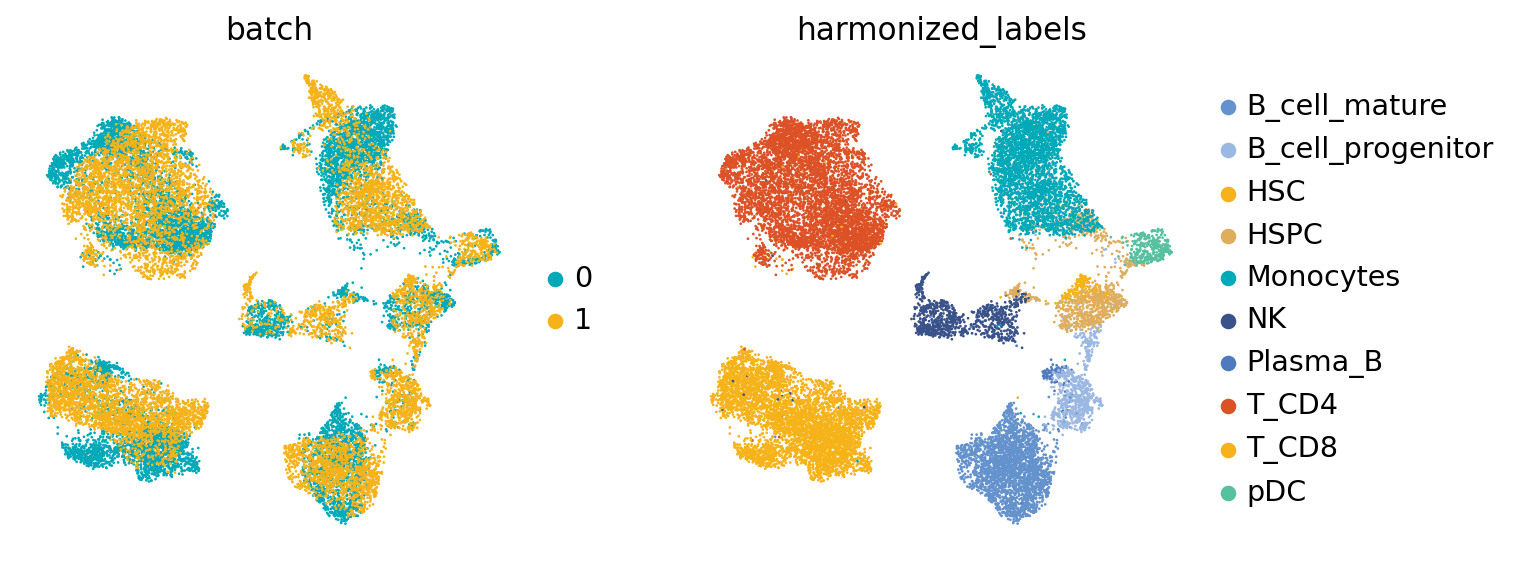

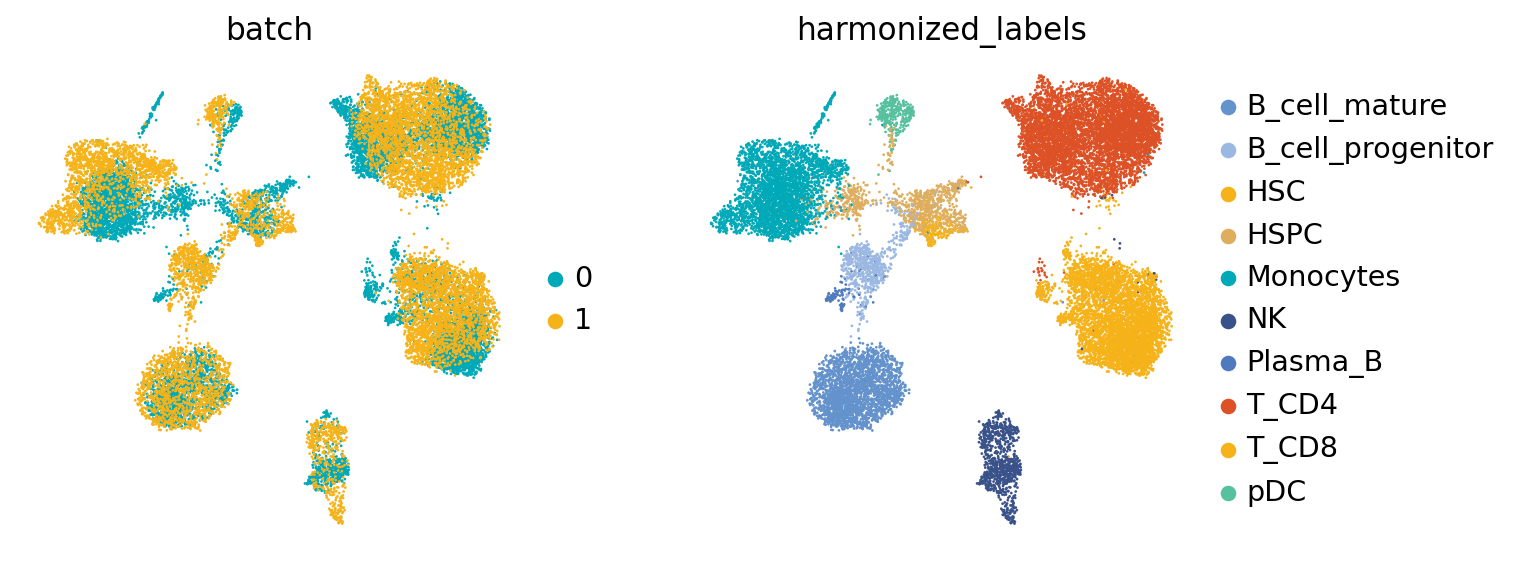

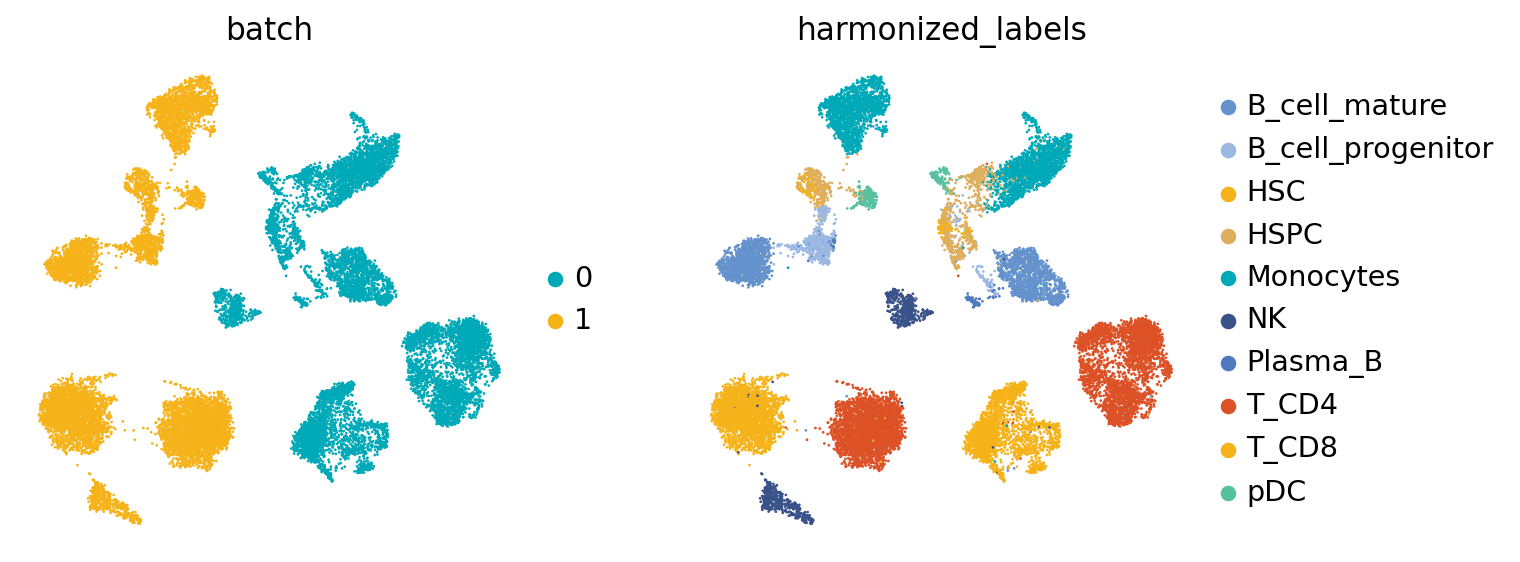

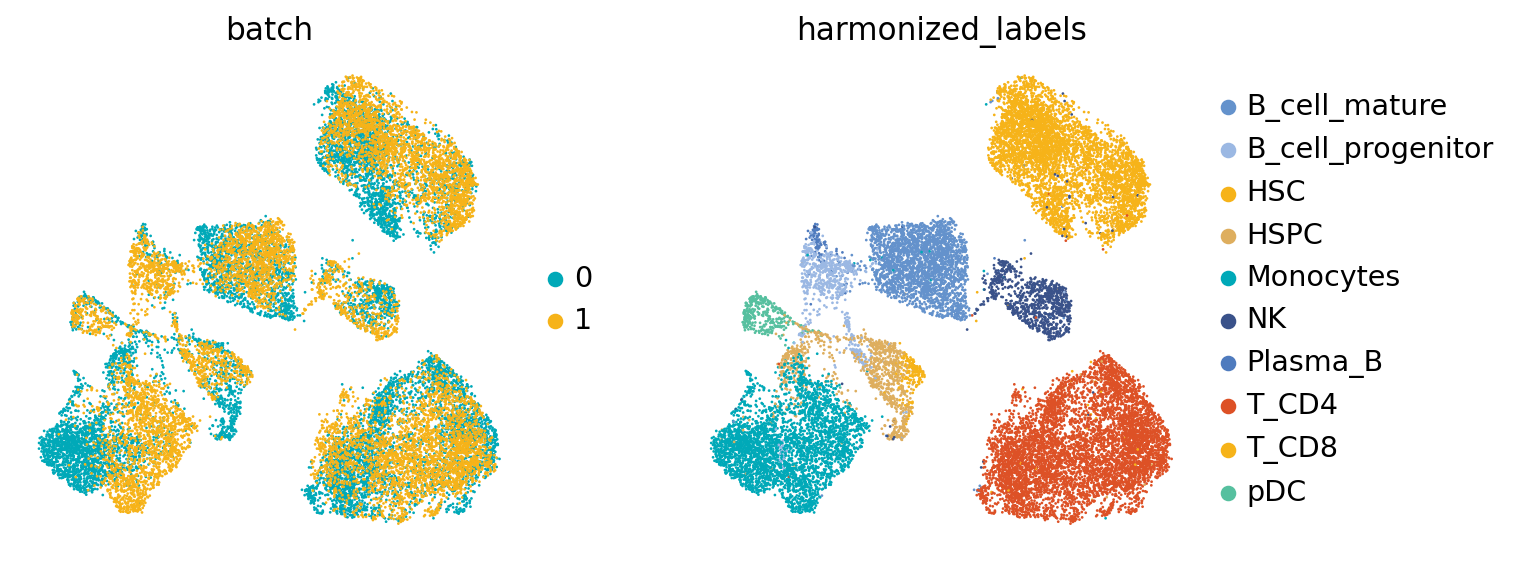

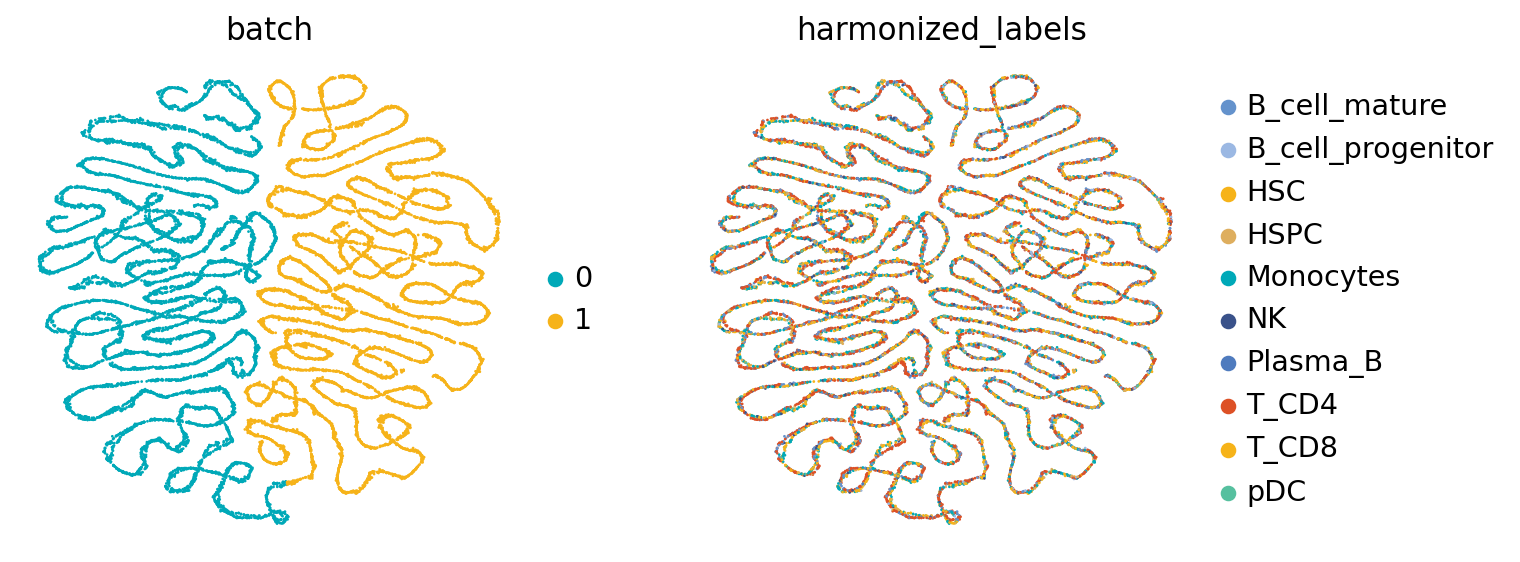

In [25]:
for key in latent_obsm_keys:
    sc.pl.embedding(adata_bm, basis =  f'X_umap_{key[2:]}', color = ['batch', 'harmonized_labels'], frameon=False, save = f'embedding_cross_int_MARIO_subset{key[2:]}.png')

# Runtime comparison

In [9]:
# read results
model_path = '/home/projects/amit/floriani/Lab/PROJECTS/FlowVI/models/cross_tech_int/2025-08-20_Levine_Stuart'

runtime_res_py = pd.read_csv(f'{model_path}/2026-03-31_Levine_Stuart_Runtime_CytoVI_Harmony.csv').rename(columns={'Unnamed: 0': 'method'})
runtime_res_r = pd.read_csv(f'{model_path}/2026-03-31_Levine_Stuart_Runtime_FastMNN_Cycombine.csv').rename(columns={'Unnamed: 0': 'method'})
runtime_res_mario = pd.read_csv(f'{model_path}/2026-03-31_Levine_Stuart_Runtime_MARIO.csv').rename(columns={'Unnamed: 0': 'method'})
runtime_res = pd.concat([runtime_res_py, runtime_res_r, runtime_res_mario], ignore_index=True, axis=0)
runtime_res['n_obs']  = runtime_res['method'].str.rsplit('_', n=1).str[-1].astype(int)
runtime_res['method'] = runtime_res['method'].str.rsplit('_', n=1).str[0]

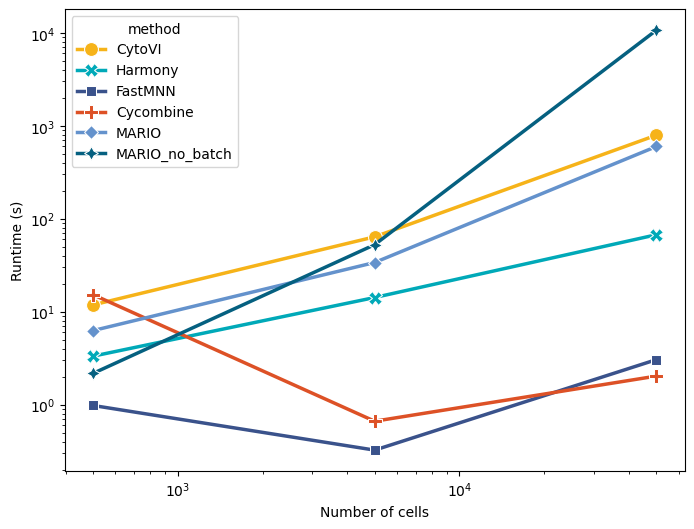

In [13]:
# plot results
palette = ['#F6B319', '#00A9B8', '#3A528B', '#DD5126', '#6492CC','#056080']

plt.figure(figsize=(8, 6))
sns.lineplot(data=runtime_res, x='n_obs', y='time', hue='method', style='method', markers=True, dashes=False, palette=palette, linewidth=2.5, markersize=10)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of cells')
plt.ylabel('Runtime (s)')
plt.savefig(f'{figure_dir}Lineplot_Levine_Stuart_Runtime_CytoVI_Harmony_FastMNN_Cycombine_MARIO.pdf')